# Logistic Regression with scikit-learn


This notebook focuses on the **workflow** for implementing logistic regression with scikit-learn. You will see that the problem at hand can be solved perfectly with logistic regression. 

By the end of this notebook, you should know what steps to take in sequence to implement a model with scikit-learn and be able to apply it to unseen data.


## Data

To start with a simple example, let’s say that your goal is to build a logistic regression model in Python in order to determine whether candidates would get admitted to a prestigious university.

Here, there are two possible outcomes: Admitted (represented by the value of ‘1’) vs. Rejected (represented by the value of ‘0’).

You can then build a logistic regression in Python, where:

The dependent variable represents whether a person gets admitted and the 3 independent variables are the GMAT score, GPA and Years of work experience.

In [2]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score

# I add these line
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
#from sklearn.model_selection  import cross_val_score
#from sklearn.metrics import roc_curve,plot_roc_curve, balanced_accuracy_score

In [3]:
# Generating the data
candidates = {'gmat': [780,750,690,710,680,730,690,720,740,690,610,690,710,680,770,610,580,650,540,590,620,600,550,550,570,670,660,580,650,660,640,620,660,660,680,650,670,580,590,690],
              'gpa': [4,3.9,3.3,3.7,3.9,3.7,2.3,3.3,3.3,1.7,2.7,3.7,3.7,3.3,3.3,3,2.7,3.7,2.7,2.3,3.3,2,2.3,2.7,3,3.3,3.7,2.3,3.7,3.3,3,2.7,4,3.3,3.3,2.3,2.7,3.3,1.7,3.7],
              'work_experience': [3,4,3,5,4,6,1,4,5,1,3,5,6,4,3,1,4,6,2,3,2,1,4,1,2,6,4,2,6,5,1,2,4,6,5,1,2,1,4,5],
              'admitted': [1,1,1,1,1,1,0,1,1,0,0,1,1,1,1,0,0,1,0,0,0,0,0,0,0,1,1,0,1,1,0,0,1,1,1,0,0,0,0,1]
              }

df = pd.DataFrame(candidates,columns= ['gmat', 'gpa','work_experience','admitted'])
df.head()

,gmat,gpa,work_experience,admitted
0,780,4.0,3,1
1,750,3.9,4,1
2,690,3.3,3,1
3,710,3.7,5,1
4,680,3.9,4,1


In [4]:
# Defining target and predictors 
X = df[['gmat', 'gpa','work_experience']]
y = df['admitted']

In [5]:
# Train-test-split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

## Create Logistic Regression

In [6]:
# Modelling
logistic_regression = LogisticRegression()
logistic_regression.fit(X_train, y_train)
y_pred = logistic_regression.predict(X_test)
# new line
#y_pred_prob = logistic_regression.predict_proba(X_test)

### Confusion Matrix

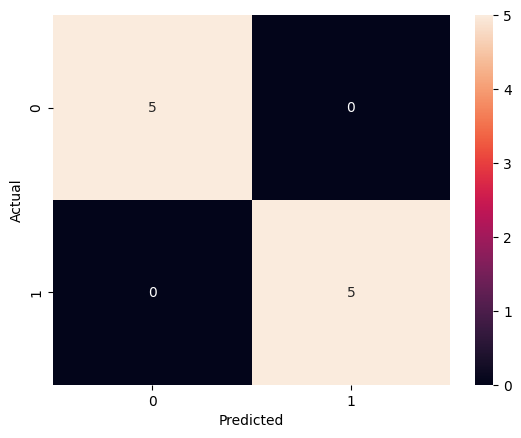

In [7]:
# Confusion matrix using pandas crosstab
conf_matrix= pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])
sns.heatmap(conf_matrix, annot=True);

In [8]:
print(y_pred)

[0 0 1 1 0 0 1 1 0 1]


In [9]:
print(y_test)

22    0
20    0
25    1
4     1
10    0
15    0
28    1
11    1
18    0
29    1
Name: admitted, dtype: int64


In [10]:
print('Accuracy: ', accuracy_score(y_test, y_pred))

Accuracy:  1.0


In [11]:
confusion_matrix(y_test, y_pred)

array([[5, 0],
       [0, 5]])

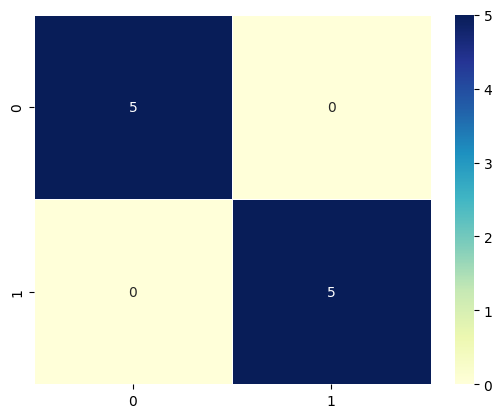

In [12]:
# Confusion matrix using the confusion_matrix function from sklearn
cfm = confusion_matrix(y_test, y_pred)
sns.heatmap(cfm, cmap='YlGnBu', annot=True, fmt='d', linewidths=.5);

**Check your understanding**

- Check out the Scikit-Learn documentation for logistic regression and find out how to output the estimated parameters of your model.

- Scikit-Learn usually has pretty good default values set for the hyperparameters of models. Try printing out all the defined hyperparameters of your model and check what these hyperparameters mean and what other options would be available for these hyperparameters.

- Try to change the threshold to 0.3 and print out the confusion matrix for this threshold. 

<details><summary>
Click here for a hint for the last task
</summary>
You need to output the predicted probabilities of your model and use a function that gives you a value of 0 if the predicted probability is less than/equal to 0.3 and 1 if it is above the threshold. Now you can use this array as y_pred to print the confusion matrix.
</details>


In [13]:
#https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
#https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression

 class sklearn.linear_model.LogisticRegression(penalty='l2', *, dual=False, tol=0.0001, C=1.0, fit_intercept=True, intercept_scaling=1, class_weight=None, random_state=None, solver='lbfgs', max_iter=100, multi_class='auto', verbose=0, warm_start=False, n_jobs=None, l1_ratio=None)[source]

class sklearn.linear_model.LogisticRegression(penalty='l2', *, dual=False, tol=0.0001, C=1.0, fit_intercept=True, intercept_scaling=1, class_weight=None, random_state=None, solver='lbfgs', max_iter=100, multi_class='auto', verbose=0, warm_start=False, n_jobs=None, l1_ratio=None)[source]¶

In [14]:
#the logit is the inverse of the standard logistic function

[0 1]
Accuracy:  1.0


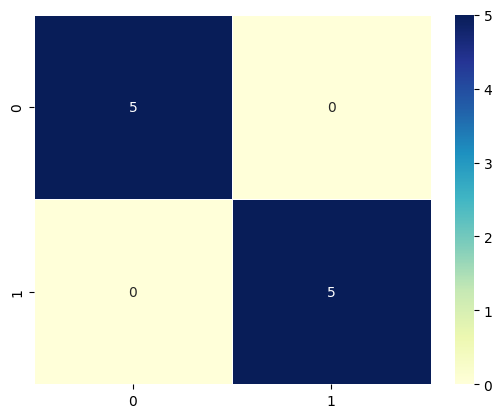

In [15]:
y_pred_prob = logistic_regression.predict_proba(X_test)
print(logistic_regression.classes_)# this print clasess
thrsh = 0.5
#y_pred_prob[:,0] - p
#y_pred_prob[:,1] - (1-p)
#first column will flip y_pred
#second column will be same as y_pred
#y_pred_thrsh = [1 if p < thrsh else 0 for p in y_pred_prob[:,0]]
y_pred_thrsh = [0 if p <= thrsh else 1 for p in y_pred_prob[:,1]]
confusion_matrix(y_test, y_pred_thrsh)
print('Accuracy: ', accuracy_score(y_test, y_pred_thrsh))
cfm1 = confusion_matrix(y_test, y_pred_thrsh)
sns.heatmap(cfm1, cmap='YlGnBu', annot=True, fmt='d', linewidths=.5);
#print(thrsh, y_pred, y_pred_thrsh, y_pred_prob,  y_pred_prob[:,1])
#see this link to accuracy 
#https://stackoverflow.com/questions/36681449/scikit-learn-return-value-of-logisticregression-predict-proba

In [16]:
print(y_pred, y_pred_prob.round(3))

[0 0 1 1 0 0 1 1 0 1] [[0.998 0.002]
 [0.98  0.02 ]
 [0.009 0.991]
 [0.046 0.954]
 [0.973 0.027]
 [0.998 0.002]
 [0.023 0.977]
 [0.008 0.992]
 [1.    0.   ]
 [0.062 0.938]]


In [17]:
# Some useful links
#https://medium.com/@24littledino/define-threshold-of-logistic-regression-in-python-56c60664fc3e
#https://stackoverflow.com/questions/28716241/controlling-the-threshold-in-logistic-regression-in-scikit-learn#:~:text=Logistic%20regression%20chooses%20the%20class,lectures%2C%20the%20bottom%20lines).

In [18]:
#b
#penality- regularization

In [19]:
#https://towardsdatascience.com/metrics-to-evaluate-your-machine-learning-algorithm-f10ba6e38234

In [20]:
# May be I would like to try this one
#https://towardsdatascience.com/stop-using-0-5-as-the-threshold-for-your-binary-classifier-8d7168290d44
#https://towardsdatascience.com/stop-using-0-5-as-the-threshold-for-your-binary-classifier-8d7168290d44

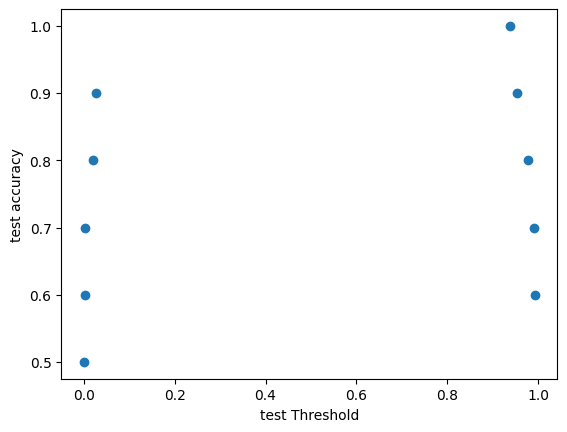

In [21]:
model = LogisticRegression()
model.fit(X_train,y_train)
#model.fit(X_test,y_test)
threshold = []
accuracy = []
for p in np.unique(model.predict_proba(X_test)[:,1]):
  threshold.append(p)
  y_pred_prob = (model.predict_proba(X_test)[:,1] >= p).astype(int)
  accuracy.append(accuracy_score(y_test,y_pred_prob))
plt.scatter(threshold,accuracy)
plt.xlabel("test Threshold")
plt.ylabel("test accuracy")
plt.show()

[0 1]
Accuracy:  1.0


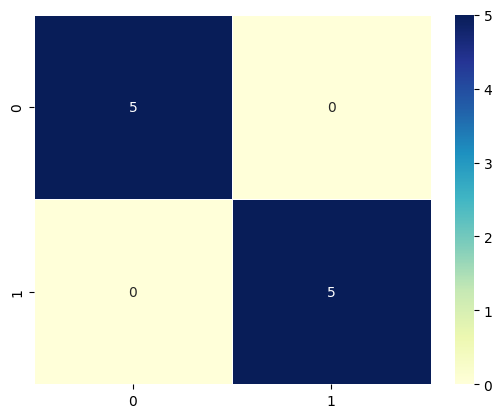

In [22]:
y_pred_prob = logistic_regression.predict_proba(X_test)
print(logistic_regression.classes_)# this print clasess
thrsh = 0.5
#y_pred_prob[:,0] - p
#y_pred_prob[:,1] - (1-p)
#first column will flip y_pred
#second column will be same as y_pred
#y_pred_thrsh = [1 if p < thrsh else 0 for p in y_pred_prob[:,0]]
y_pred_thrsh = [0 if p <= thrsh else 1 for p in y_pred_prob[:,1]]
confusion_matrix(y_test, y_pred_thrsh)
print('Accuracy: ', accuracy_score(y_test, y_pred_thrsh))
cfm1 = confusion_matrix(y_test, y_pred_thrsh)
sns.heatmap(cfm1, cmap='YlGnBu', annot=True, fmt='d', linewidths=.5);

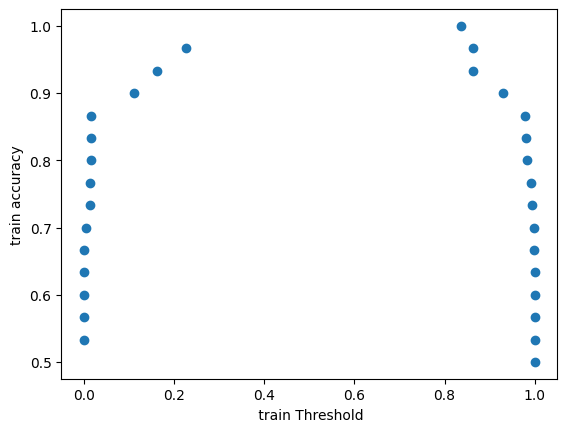

In [23]:
model = LogisticRegression()
model.fit(X_train,y_train)
threshold = []
accuracy = []
for p in np.unique(model.predict_proba(X_train)[:,1]):
  threshold.append(p)
  y_pred = (model.predict_proba(X_train)[:,1] >= p).astype(int)
  accuracy.append(accuracy_score(y_train,y_pred))
plt.scatter(threshold,accuracy)
plt.xlabel(" train Threshold")
plt.ylabel("train accuracy")
plt.show()

Answer by Kavish
3. Try different Thresholds
y_pred = [1 if x >= 0.5 else 0 for x in list(lr.predict_proba(X_test)[:,1])]

I don't think Threshold 0.3 would make a difference as probabilities are almost 98-99% for the classes

In [ ]:
import matplotlib.pyplot as plt

from sklearn.metrics import precision_recall_curve, auc

y_pred_proba = logistic_regression.predict_proba(X_test)

#retrieve probability of being 1(in second column of y_pred_proba)
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba[:, 1]) 

pr_auc = auc(recall, precision)

plt.title("Precision-Recall vs Threshold Chart")
plt.plot(thresholds, precision[: -1], "b--", label="Precision")
plt.plot(thresholds, recall[: -1], "r--", label="Recall")
plt.ylabel("Precision, Recall")
plt.xlabel("Threshold")
plt.legend(loc="lower left")
plt.ylim([0,1])